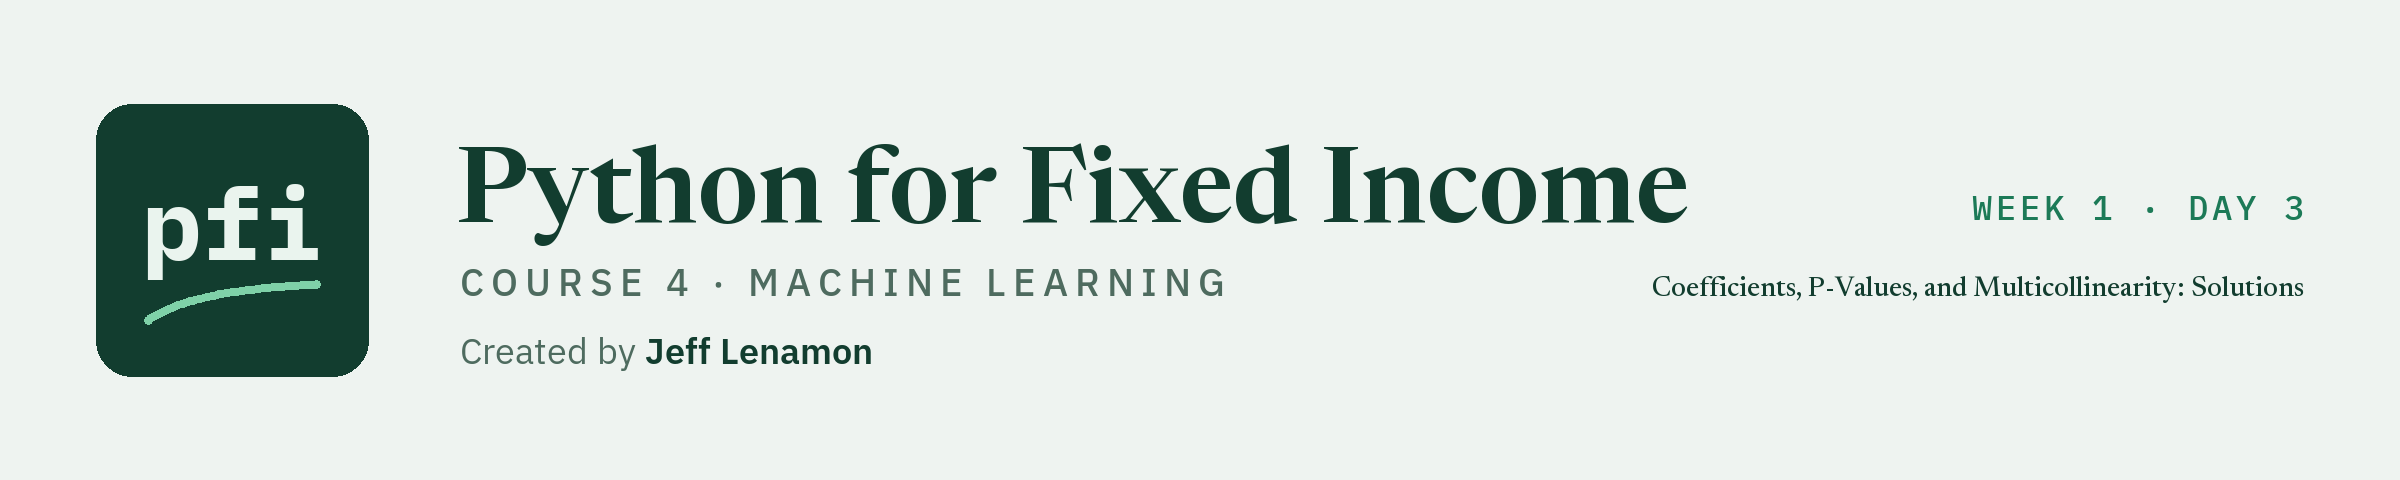

# Coefficients, P-Values, and Multicollinearity: Solutions

Week 1, Day 3. Worked answers to the exercises. Try each one yourself first.

**Data:** `benchmark.csv` and `ratings.csv`, 821 bonds of invented issuers: **synthetic**, made for this course by `tools/make_holdings.py`. No real issuer, price, or spread.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course4_machine_learning/week1/day3/03_coefficients_p_values_and_multicollinearity_solutions.ipynb)

This notebook stands on its own. Its setup writes `mlkit.py` and `test_mlkit.py` as they stand at the end of today, so the exercises can be run without the lesson.

Q. Set up today's work folder.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, or scikit-learn is imported: if you ran another cell first,
# restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# four packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("pytest", "pytest")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course4_machine_learning/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "statsmodels": "0.15.0", "scipy": "1.18.1", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "benchmark.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course4_03_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["benchmark.csv", "ratings.csv", "course4_excel_reference.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, statsmodels 0.15.0, scipy 1.18.1, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course4_03_k3phm4e2, in your temp folder
Data files from the data folder of the course repo: benchmark.csv, ratings.csv, course4_excel_reference.csv
SEED = 42


Q. Write `mlkit.py` and `test_mlkit.py` as they stand at the end of today.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, because statsmodels refuses booleans. The reference is named by the caller,
    never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)

Writing mlkit.py


In [3]:
%%writefile test_mlkit.py
"""Tests for mlkit.py.

Expected values come from Excel (course4_excel_reference.csv in this folder), from scikit-learn or statsmodels on
the same inputs, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

import mlkit

HERE = Path(__file__).resolve().parent
SEED = 42


def read_bench() -> pd.DataFrame:
    """The 821 synthetic benchmark bonds joined to their rating score, with log_oas (natural log of bp)."""
    bench = pd.read_csv(HERE / "benchmark.csv")
    ratings = pd.read_csv(HERE / "ratings.csv")
    bench = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    bench["log_oas"] = np.log(bench["oas"])
    return bench


def excel(case_id: str) -> float:
    """One value computed by Excel, looked up by its case_id (model:quantity)."""
    reference = pd.read_csv(HERE / "course4_excel_reference.csv", float_precision="round_trip")
    return float(reference.set_index("case_id").loc[case_id, "excel_value"])


def test_assert_disjoint_passes():
    mlkit.assert_disjoint([0, 1, 2], [3, 4])


def test_assert_disjoint_raises_with_count():
    with pytest.raises(AssertionError, match="2 row labels"):
        mlkit.assert_disjoint([0, 1, 2, 3], [2, 3, 4])


def test_regression_metrics_hand_values():
    # errors 10, -10, 30 bp around a mean of 200 bp
    metrics = mlkit.regression_metrics([100.0, 200.0, 300.0], [110.0, 190.0, 330.0])
    assert metrics["mae"] == pytest.approx(50 / 3, abs=1e-12)
    assert metrics["rmse"] == pytest.approx(np.sqrt(1100 / 3), abs=1e-12)
    # SS_res 1,100 over SS_tot 20,000
    assert metrics["r2"] == pytest.approx(1 - 1100 / 20000, abs=1e-12)


def test_regression_metrics_match_sklearn():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(r2_score(bench["oas"], fitted), abs=1e-12)
    assert metrics["mae"] == pytest.approx(mean_absolute_error(bench["oas"], fitted), abs=1e-12)
    assert metrics["rmse"] == pytest.approx(root_mean_squared_error(bench["oas"], fitted), abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.regression_metrics([1.0, 2.0], [1.0])


def test_slope_matches_excel_reference():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    # Excel: =SLOPE(oas, score), =INTERCEPT(oas, score), =RSQ(oas, score) over the 821 bonds
    assert slope == pytest.approx(excel("d01_oas_on_score:slope"), abs=1e-9)
    assert intercept == pytest.approx(excel("d01_oas_on_score:intercept"), abs=1e-9)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(excel("d01_oas_on_score:rsq"), abs=1e-9)
    # Excel: =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)), in bp
    assert metrics["mae"] == pytest.approx(excel("d01_oas_on_score:mae_bp"), abs=1e-9)
    assert metrics["rmse"] == pytest.approx(excel("d01_oas_on_score:rmse_bp"), abs=1e-9)


import statsmodels.api as sm


def rating_levels() -> list[str]:
    """Every rating level, AAA to CCC, in the order of ratings.csv."""
    return pd.read_csv(HERE / "ratings.csv")["rating"].tolist()


def sector_dummies(sectors: pd.Series, reference: str = "Consumer") -> pd.DataFrame:
    """One float column per sector except the reference, named sector_<name>, in alphabetical order."""
    return pd.DataFrame({f"sector_{s}": (sectors == s).astype(float) for s in sorted(sectors.unique())
                         if s != reference}, index=sectors.index)


def test_adjusted_r2_hand_value():
    # 1 - (1 - 0.8) x 99 / 96
    assert mlkit.adjusted_r2(0.8, 100, 3) == pytest.approx(1 - 0.2 * 99 / 96, abs=1e-12)


def test_adjusted_r2_rejects_too_few_rows():
    with pytest.raises(ValueError):
        mlkit.adjusted_r2(0.8, 4, 3)


def test_rating_dummies_reference_absent():
    ratings = pd.Series(["AAA", "A", "BBB", "A"])
    dummies = mlkit.rating_dummies(ratings, ["AAA", "A", "BBB"], reference="A")
    assert list(dummies.columns) == ["rating_AAA", "rating_BBB"]
    # an A-rated bond has every indicator at 0.0: the intercept stands for it
    assert dummies.loc[1].tolist() == [0.0, 0.0]
    assert dummies.dtypes.eq(float).all()


def test_rating_dummies_unknown_level_raises():
    with pytest.raises(ValueError, match="BB"):
        mlkit.rating_dummies(pd.Series(["AAA", "BB"]), ["AAA", "A"], reference="A")
    with pytest.raises(ValueError):
        mlkit.rating_dummies(pd.Series(["AAA"]), ["AAA", "A"], reference="CCC")


def test_linest_multi_matches_excel_reference():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["oas"], sm.add_constant(X)).fit()
    model = "d02_oas_on_rating_duration_sector"
    # Excel's LINEST reverses the columns; the reference file names each value in statsmodels' order
    for name in ["const"] + list(X.columns):
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
    assert fit.rsquared == pytest.approx(excel(f"{model}:r2"), abs=1e-9)
    assert fit.df_resid == excel(f"{model}:df_resid")
    assert fit.fvalue == pytest.approx(excel(f"{model}:f"), rel=1e-9)
    adjusted = mlkit.adjusted_r2(fit.rsquared, len(X), X.shape[1])
    assert adjusted == pytest.approx(excel(f"{model}:adj_r2"), abs=1e-9)
    assert adjusted == pytest.approx(fit.rsquared_adj, abs=1e-12)


from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor


def m3_features(bench: pd.DataFrame) -> pd.DataFrame:
    """Rating score, duration, and the nine sector dummies (reference Consumer): the day 3 inference model."""
    return pd.concat([bench[["score", "duration"]], sector_dummies(bench["sector"])], axis=1)


def test_vif_matches_statsmodels():
    X = m3_features(read_bench())
    vifs = mlkit.vif_table(X)
    with_constant = sm.add_constant(X).to_numpy()
    for j, name in enumerate(X.columns, start=1):
        assert vifs[name] == pytest.approx(variance_inflation_factor(with_constant, j), abs=1e-9), name
    # sorted from the highest VIF down
    assert vifs.is_monotonic_decreasing


def test_vif_matches_excel_reference():
    vifs = mlkit.vif_table(m3_features(read_bench()))
    for name, value in vifs.items():
        # Excel: =1/(1-INDEX(LINEST(xj, the other columns, TRUE, TRUE), 3, 1))
        assert value == pytest.approx(excel(f"d03_vif:vif_{name}"), abs=1e-9), name


def test_vif_perfect_collinearity_is_huge():
    bench = read_bench()
    # spread_duration equals duration on every bond of the file
    vifs = mlkit.vif_table(bench[["score", "duration", "spread_duration"]])
    assert vifs["duration"] > 1e10
    assert vifs["spread_duration"] > 1e10
    assert vifs["score"] < 5


def test_ols_matches_sklearn():
    bench = read_bench()
    X = m3_features(bench)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    linear = LinearRegression().fit(X, bench["log_oas"])
    assert linear.intercept_ == pytest.approx(fit.params["const"], abs=1e-9)
    for name, value in zip(X.columns, linear.coef_):
        assert value == pytest.approx(fit.params[name], abs=1e-9), name
    # and both against Excel's LINEST, with its standard errors and T.DIST.2T p-values
    model = "d03_log_oas_on_score_duration_sector"
    for name in fit.params.index:
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
        assert fit.pvalues[name] == pytest.approx(excel(f"{model}:p_{name}"), abs=1e-9), name

Writing test_mlkit.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)

# the functions defined in the module itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(mlkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "mlkit" and not name.startswith("_")]
print(f"mlkit functions: {functions}")

mlkit functions: ['assert_disjoint', 'regression_metrics', 'adjusted_r2', 'rating_dummies', 'vif_table']


## Exercises

The exercises use the same 821 synthetic bonds: their spreads come from the course's generator, not from a market. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the bonds, builds today's features, makes the course split, fits section 3.1's model in statsmodels, fits the OAS model on score and duration that Exercise 4 compares with, and defines `check`, a small function that marks your answers.

In [5]:
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# the 821 synthetic bonds with their rating score, log_oas, and years to maturity
bench = pd.read_csv("benchmark.csv", float_precision="round_trip")
ratings = pd.read_csv("ratings.csv")
bench = bench.merge(ratings[["rating", "score", "grade"]], on="rating", how="left", validate="many_to_one")
bench["log_oas"] = np.log(bench["oas"])

# section 3.1: score, duration, and the sector dummies (reference Consumer), the course split, the statsmodels fit
sectors = pd.get_dummies(bench["sector"], prefix="sector", dtype=float).drop(columns="sector_Consumer")
X = pd.concat([bench[["score", "duration"]], sectors], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, bench["log_oas"], test_size=0.25, random_state=SEED)
fit = sm.OLS(y_train, sm.add_constant(X_train)).fit()

# the OAS model on score and duration, in bp, on the same split: Exercise 4 compares with it
O_train, O_test, oas_train, oas_test = train_test_split(bench[["score", "duration"]], bench["oas"], test_size=0.25,
                                                        random_state=SEED)
base_metrics = mlkit.regression_metrics(oas_test, LinearRegression().fit(O_train, oas_train).predict(O_test))


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Add `coupon` to the training features (`X_train` plus the training rows' `coupon` column) and compute the VIFs with `mlkit.vif_table`. Store coupon's VIF in **ex1_coupon_vif**. Is it high by the course's convention?

In [6]:
# the training features plus each training bond's coupon
X_train_coupon = pd.concat([X_train, bench.loc[X_train.index, ["coupon"]]], axis=1)
vifs = mlkit.vif_table(X_train_coupon)
ex1_coupon_vif = vifs["coupon"]
print(f"coupon's VIF: {ex1_coupon_vif:.2f}")
vifs.round(2).head(4)

coupon's VIF: 2.10


score               2.15
sector_Telecom      2.13
sector_Materials    2.13
coupon              2.10
Name: vif, dtype: float64

* 2.10: below 5, so not high by the course's convention. Coupon overlaps with rating score (in this file coupon rises with the score, a correlation of 0.70 on the training rows), and score's own VIF rises with it, but not enough to blur either coefficient much.

In [7]:
check("Exercise 1 coupon's VIF", ex1_coupon_vif, 2.0994840482358375)

Exercise 1 coupon's VIF: correct


### Exercise 2

Q. From `fit`, take the 95 percent interval on duration's coefficient (`fit.conf_int()`) and turn both ends into percent per year of duration with 100 x (exp(b) - 1). Store them in **ex2_low_pct** and **ex2_high_pct**.

In [8]:
# the interval in log_oas units, then each end as a percent change in the spread per year of duration
low, high = fit.conf_int(alpha=0.05).loc["duration"]
ex2_low_pct = 100 * (np.exp(low) - 1)
ex2_high_pct = 100 * (np.exp(high) - 1)
print(f"duration: {ex2_low_pct:.2f} to {ex2_high_pct:.2f} percent per year, in this file")

duration: 1.33 to 2.65 percent per year, in this file


* 1.33 to 2.65 percent per year of duration. The sign is clear; the size is known to within a factor of two. And section 3.4 still applies: the number describes how spreads line up with duration in an invented file whose recipe uses maturity, not what duration does to a spread.

In [9]:
check("Exercise 2 the low end", ex2_low_pct, 1.3268799553997512)
check("Exercise 2 the high end", ex2_high_pct, 2.649559448161787)

Exercise 2 the low end: correct
Exercise 2 the high end: correct


### Exercise 3

Q. Add a function to your module. `significant(coef_table, level)` returns the names of the coefficients whose p-value is below `level`, in the table's order. `coef_table` is indexed by name and has a column `p_value`; the function raises `ValueError` if `level` is not between 0 and 1 or the column is missing. Write the docstring first, saying what the list does and does not mean. Then add `test_significant_hand_table`, with a small table you can check by eye (include a p-value of exactly 0.05). Run pytest, reload the module, and store `mlkit.significant(pd.DataFrame({"coef": fit.params, "p_value": fit.pvalues}), 0.05)` in **ex3_names**.

Write the function in the cell that starts with `%%writefile -a mlkit.py` and the test in the one that starts with `%%writefile -a test_mlkit.py`, and run each of those cells once.

In [10]:
%%writefile -a mlkit.py


def significant(coef_table: pd.DataFrame, level: float = 0.05) -> list[str]:
    """Names of the coefficients whose p-value is below level.

    Input: coef_table, indexed by coefficient name, with a column p_value (for example from a statsmodels fit:
    pd.DataFrame({"coef": fit.params, "p_value": fit.pvalues})); level, the significance level, above 0 and
    below 1 (the course's convention is 0.05).
    Output: the names with p_value < level, in the table's order. A name on the list is distinguishable from zero
    at that level in this model; that is not a cause, and a name off the list is not shown to have no effect.
    Raises ValueError if level is not between 0 and 1, or coef_table has no p_value column.
    """
    # check the inputs before reading them
    if not 0 < level < 1:
        raise ValueError(f"level must be between 0 and 1, not {level}")
    if "p_value" not in coef_table.columns:
        raise ValueError("coef_table needs a p_value column")
    # the names whose p-value is strictly below the level
    return [name for name, p in coef_table["p_value"].items() if p < level]

Appending to mlkit.py


In [11]:
%%writefile -a test_mlkit.py


def test_significant_hand_table():
    table = pd.DataFrame({"p_value": [0.001, 0.2, 0.049, 0.05]}, index=["a", "b", "c", "d"])
    # 0.05 itself is not below 0.05
    assert mlkit.significant(table, 0.05) == ["a", "c"]
    assert mlkit.significant(table, 0.01) == ["a"]
    with pytest.raises(ValueError):
        mlkit.significant(table, 1.5)
    with pytest.raises(ValueError):
        mlkit.significant(pd.DataFrame({"p": [0.1]}), 0.05)

Appending to test_mlkit.py


In [12]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_mlkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

...............                                                          [100%]
15 passed in 4.96s



In [13]:
# the file changed, so reload before calling the new function
importlib.reload(mlkit)
ex3_names = mlkit.significant(pd.DataFrame({"coef": fit.params, "p_value": fit.pvalues}), 0.05)
print(ex3_names)

['const', 'score', 'duration']


* `15 passed`: today's 14 and the new one.
* `['const', 'score', 'duration']`: the intercept, score, and duration, and no sector. The list says which coefficients the data can tell apart from zero at 0.05 in this model. Duration is on it although the recipe never uses duration, and no sector is on it, which here is right only because we know the recipe.

In [14]:
check("Exercise 3 the names below 0.05", ex3_names, ['const', 'score', 'duration'])

Exercise 3 the names below 0.05: correct


### Exercise 4: AI check

You ask an AI assistant for a function that fits a spread model and reports its test errors, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Fit OAS (bp) on rating score, duration, and any other column that adds information, and report errors on rows it did not see.

    Every feature must be known without knowing the bond's OAS: the model gives the spread of a bond with these
    characteristics. Split: train_test_split(X, y, test_size=0.25, random_state=SEED); fit on the training rows only.
    Returns: the fitted model, the list of feature names, and regression_metrics on the test rows (mae and rmse in bp).
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns numbers of the right size, and contains one bug.

* The bug: `dts` is in the features. The file defines DTS as spread duration times OAS, so the column holds the target: its correlation with `oas` x `duration` is 1.0000. The comment makes it sound like more information ("spread risk"), and the numbers look much better: a test R-squared of 0.7193 instead of 0.5529, and a test MAE of 38.6 bp instead of 57.5 bp. The model is partly reading the answer off a feature. A model meant to give the spread of a bond with these characteristics cannot use a column you only know once you know the spread.
* The fix, in the cell below: keep only columns known without the OAS.

In [15]:
def fit_spread_model(bonds):
    """Fit OAS (bp) on rating score, duration, and any other column that adds information, and report errors on rows it did not see.

    Every feature must be known without knowing the bond's OAS: the model gives the spread of a bond with these
    characteristics. Split: train_test_split(X, y, test_size=0.25, random_state=SEED); fit on the training rows only.
    Returns: the fitted model, the list of feature names, and regression_metrics on the test rows (mae and rmse in bp).
    """
    # the fix: dts is spread duration x OAS, so it holds the target; only columns known without the OAS stay
    features = ["score", "duration"]
    X = bonds[features]
    y = bonds["oas"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
    model = LinearRegression().fit(X_train, y_train)
    metrics = mlkit.regression_metrics(y_test, model.predict(X_test))
    return model, features, metrics

In [16]:
# the test, written from the docstring before the code is trusted
ai_model, ai_features, ai_metrics = fit_spread_model(bench)

# 1. no feature is the target times a feature: such a column holds the answer
for feature in ai_features:
    for other in ai_features:
        r = np.corrcoef(bench[feature], bench["oas"] * bench[other])[0, 1]
        assert r < 0.99, f"{feature} has a correlation of {r:.4f} with oas x {other}: the target is inside a feature"
# 2. the test R-squared is the level of the model on score and duration alone
assert abs(ai_metrics["r2"] - base_metrics["r2"]) < 1e-9, "the test R-squared is not the level without the leak"
print("no feature holds the target, and the test R-squared is the honest one")

no feature holds the target, and the test R-squared is the honest one


In [17]:
ex4_test_mae_bp = fit_spread_model(bench)[2]["mae"]
print(f"fixed: test MAE {ex4_test_mae_bp:.1f} bp, the same as score and duration alone")

fixed: test MAE 57.5 bp, the same as score and duration alone


* The fixed function gives the honest numbers. Keep the test: a feature that looks too good is the first place to look for the target, and a check of each feature against the target catches it every time.

In [18]:
check("Exercise 4 the fixed function's test MAE", ex4_test_mae_bp, 57.48836096044265)

Exercise 4 the fixed function's test MAE: correct


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```